## Galaxies in Illustris

Above, we were looking at star particles in simulated galaxies, similar to how we looked at stars in the Milky Way using Gaia data. We can instead look at many galaxies' overall properties, similar to how we looked at galaxies in Galaxy Zoo. We can look at some of the fully evolved galaxies in IllustrisTNG by examining the Illustris_galaxies file in the Data folder.

In [1]:
# import library
import pandas as pd

# read in the data (Illustris_galaxies.csv)
data = pd.read_csv('../Data/Illustris_galaxies.csv')

In [2]:
# display the data set
data

,Galaxy ID,Stellar Mass [Mo],g band,r band,Probability is spiral
0,0,3.565573e+12,-23.256830,-24.071047,0.285813
1,1,5.376783e+11,-21.941610,-22.712160,0.817303
2,2,6.034437e+11,-22.199574,-22.951138,0.941455
3,3,1.650696e+11,-21.828701,-22.411537,0.998825
4,4,1.283022e+11,-20.685863,-21.426640,0.113466
...,...,...,...,...,...
12530,704187,5.030724e+09,-17.602875,-18.358276,0.411240
12531,719337,6.327700e+09,-18.095821,-18.824528,0.607696
12532,727485,5.224962e+09,-17.727982,-18.471638,0.475961
12533,738596,3.874592e+09,-17.392363,-18.134193,0.542526


**How many rows are there?** 

**Answer:** 12535

**How many columns are there?** 

**Answer:** 5

**Fill in the rows for each corresponding column**

| Column Header | Definition | Unit |
| :- | :- | :- |
| Galaxy ID |Galaxy identifier  | No unit
| Stellar Mass [Mo] |Mass of a Star |Mo 
| g band |Color magnitude (filter)  |No unit 
| r band |Color magnitude (filter)  |No unit 
| Probability is spiral |The probability that the galaxy is spiral  |No unit 

In [3]:
# create two boolean arrays for if a galaxy is a spiral galaxy or an elliptical galaxy
# use the same probability cut off that we did with the galaxy zoo
# you can assume a galaxy is elliptical if it is less than 20% chance a spiral galaxy

# Define probability of spiral
prob_spiral = data['Probability is spiral']
# Create boolean arrays
elliptical_bool = prob_spiral < 0.2
spiral_bool = prob_spiral >= 0.8

# Print the boolean arrays
print(elliptical_bool)

0        False
1        False
2        False
3        False
4         True
         ...  
12530    False
12531    False
12532    False
12533    False
12534    False
Name: Probability is spiral, Length: 12535, dtype: bool


In [4]:
print(spiral_bool)

0        False
1         True
2         True
3         True
4        False
         ...  
12530    False
12531    False
12532    False
12533    False
12534    False
Name: Probability is spiral, Length: 12535, dtype: bool


In [5]:
#fill in the name of the boolean arrays where you see $
print('The percentage of spiral galaxies is', round(sum(spiral_bool)/len(prob_spiral) * 100,2), '%')
print('The percentage of elliptical galaxies is', round(sum(elliptical_bool)/len(prob_spiral) * 100,2), '%')

The percentage of spiral galaxies is 26.18 %
The percentage of elliptical galaxies is 11.76 %


**What percentage of these galaxies are spirals?**

**Answer:** 26.18

**What percentage of these galaxies are ellipticals?**

**Answer:** 11.76

**How do these percentages compare to the ones you found in the Galaxy Zoo data?**

**Answer:** They are a little less than the Galaxy Zoo data but similar. There are more spiral galaxies than elliptical.

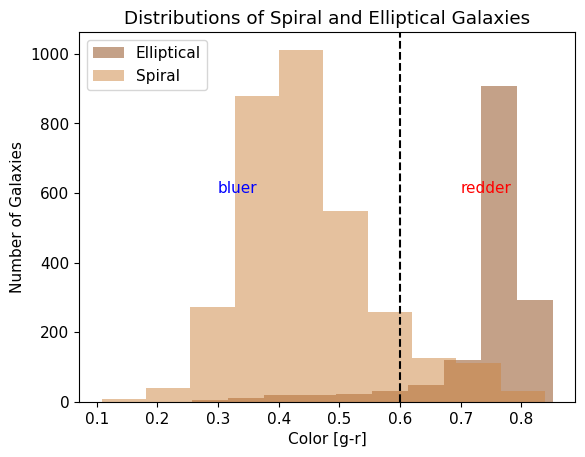

In [6]:
# create a single plot showing histograms of the colors of the two types of galaxies 

# import our graphing package and numpy
import numpy as np
import matplotlib.pyplot as plt

#the below is optional but makes the font a size I can read more easily
import matplotlib
matplotlib.rc('font', **{'family':'sans-serif', 'size':11}) 

# calculate color
g_band = data['g band']
r_band = data['r band']
g_r = g_band - r_band

# separate into spiral and elliptical
color_elliptical = g_r[elliptical_bool]
color_spiral = g_r[spiral_bool]

# create one histogram with elliptical and spiral galaxies on it

# For elliptical
plt.hist(color_elliptical, color='saddlebrown', alpha=0.5, label='Elliptical')
# For spiral
plt.hist(color_spiral, color='peru', alpha=0.5, label='Spiral')
# Create histogram
plt.title('Distributions of Spiral and Elliptical Galaxies')
plt.xlabel('Color [g-r]')
plt.ylabel('Number of Galaxies')

# Add vertical line
plt.axvline(0.6, color='black', ls='--')
# Add text
plt.text(0.3, 600, 'bluer', color='blue')
plt.text(0.7, 600, 'redder', color='red')

plt.legend()
# statistics -- find the mean and standard deviations of the color for spirals and ellipticals
# print the stats below

**Are your results consistent with what you found in Galaxy Zoo?**

**Answer:** No, because in Galaxy Zoo Elliptical galaxies are a lot more than Spiral and here, the Spiral galaxies are slightly more than the Elliptical.

## Mergers

So far, we have confirmed that in at least some ways, the simulated galaxies behave like observed ones! Cool, but let's learn something new! I said that we can use galaxy simulations to learn about mergers. Let's do that! Read in the mergers files and check out what it contains. 

In [7]:
# read in the file mergers.csv
mergers = pd.read_csv('../Data/Illustris_mergers.csv')

In [8]:
# examine the data
mergers

,Galaxy ID,Time Since Last Major Merger [Gyr],Number of Major Mergers,Numbber of Minor Mergers
0,11,3.512781,15,16
1,13,8.213934,2,5
2,19,11.317041,4,3
3,21,10.714254,2,3
4,22,12.259335,4,3
...,...,...,...,...
4995,835641,12.259335,2,0
4996,840101,13.800000,0,1
4997,880399,11.317041,1,1
4998,881510,12.804876,2,0


**How many rows are there?** 

**Answer:** 5000

**How many columns are there?**

**Answer:** 4

**Fill in the rows for each corresponding column**

| Column Header | Definition | Unit |
| :- | :- | :- |
| Galaxy ID |Galaxy identifier  |No unit 
| Time Since Last Major Merger [Gyr] |The time since the galaxies last huge merger |Giga year
| Number of Major Mergers |How many huge merger are there  |No unit 
| Number of Minor Mergers |How many small merger are there  |No unit

# Deliverable

Explore the galaxy data you have in this notebook to make at least one plot that tells us something we haven't explored! Be ready to present. You might want to include statistics.

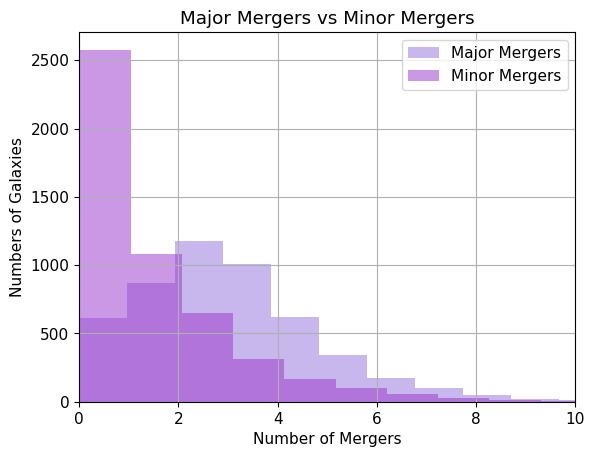

In [17]:
# explore the data and make a plot below!

# Define the data that I want to input in the scatter plot
major_mergers = mergers['Number of Major Mergers']
minor_mergers = mergers['Numbber of Minor Mergers']

# Create the plot

# Histogram of Major Mergers
plt.hist(major_mergers, bins=30, color='mediumpurple', alpha=0.5, label='Major Mergers')
# Histogram of Minor Mergers
plt.hist(minor_mergers, bins=30, color='darkorchid', alpha=0.5, label='Minor Mergers')

plt.title('Major Mergers vs Minor Mergers')
plt.ylabel('Numbers of Galaxies')
plt.xlabel('Number of Mergers')
plt.xlim(0,10)

plt.grid()
plt.legend()

In [14]:
# Statistics
print('The average Major Mergers is: ', round(np.mean(major_mergers),2))
print('The average Minor Mergers is: ', round(np.mean(minor_mergers),2))
print('')

print('The standard deviation of Major Mergers is: ', round(np.std(major_mergers),2))
print('The standard deviation of Minor Mergers is : ', round(np.std(minor_mergers),2))

The average Major Mergers is:  2.64
The average Minor Mergers is:  1.83

The standard deviation of Major Mergers is:  2.04
The standard deviation of Minor Mergers is :  1.87


**According to your graph set up...**

**What is the independent variable?**

**Answer:** Number of Mergers


**What is the dependent variable?**

**Answer:** Number of Galaxies


**What could a control variable be?**

**Answer:** Simulated galaxies

**What shapes or trends do you see in the data?**

**Answer:** For the minor galaxies, the amount of galaxies that have merger from 0-1 are about 2500 and it decrease drastically for about 1000 galaxies on 1-2 mergers and the number of galaxies continue to decrease as the number of mergers got higher. Whereas for the major merger, when the number of merger is 0-1, the starting point is very low compared to the major merger but it continues to increase when the number of galaxies are about 700-1200 and it slowly decreasing as the number of mergers got bigger and the number of galaxies got smaller.

**What could this mean physically/astronomically?**

**Answer:** As the number of galaxies got smaller, the number of mergers gets bigger. 

**What further questions does this raise?**

**Answer:** 

## Reflection

Write down some notes in your lab notebook about what you've learned in this unit about simulated galaxies. Be sure to include some astronomy and some coding. 